# Solver Engineering - Constraint-Axis Deep Dive on `01c_20x40_edges`

Sibling to [05_solver-engineering.ipynb](05_solver-engineering.ipynb). That notebook fixed the *constraint* (2-triangle) and varied the *Jacobian method* (finite-diff, analytical, analytical + warm-start) to diagnose a status-8 SLSQP failure. This one keeps the same hard case but flips the axis: fix the Jacobian/warm-start setup to the best one identified in 05 and vary the *constraint formulation*:

- **(A) CD-constraint SLSQP** - `jacobian_det2D(phi) >= threshold` per pixel (central-difference Jdet).
- **(B) FD-constraint SLSQP** - `forward_diff_Jdet(phi) >= threshold` per cell (one-sided stencil at each cell's TL corner).
- **(C) 2-triangle constraint + analytical Jacobian + warm-start** (best setup from 05).

Target case: `01c_20x40_edges`, 800 pixels / 1600 variables. Previously showed that CD-SLSQP reports `success=True` at `nit=2` while leaving 64 geometric folds in place; 2-triangle with the combined fix is the only variant that drives every measure to zero.

Color convention: red = positive / valid, blue = negative / folded (`RdBu_r`).

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint
from scipy.sparse import csr_matrix

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_2d
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.jacobian.intersection import has_quad_self_intersections, _quads_intersect
from dvfopt.core.objective import objective_euc
from dvfopt.viz.triangle_debug import find_problematic_pixels
from dvfopt.viz import plot_triangle_debug

from test_cases import make_deformation

THRESHOLD = DEFAULT_PARAMS['threshold']
print(f'threshold = {THRESHOLD}')

threshold = 0.01


In [2]:
def _forward_jdet_2d(dy, dx):
    ddx_dx = dx[:-1, 1:]  - dx[:-1, :-1]
    ddy_dy = dy[1:,  :-1] - dy[:-1, :-1]
    ddx_dy = dx[1:,  :-1] - dx[:-1, :-1]
    ddy_dx = dy[:-1, 1:]  - dy[:-1, :-1]
    return (1 + ddx_dx) * (1 + ddy_dy) - ddx_dy * ddy_dx


def measure(phi):
    jd = np.squeeze(jacobian_det2D(phi))
    fd = _forward_jdet_2d(phi[0], phi[1])
    tri = triangle_sign_areas2D(phi)
    return dict(
        jd=jd, fd=fd, tri=tri,
        n_cd=int((jd <= 0).sum()),
        n_fd=int((fd <= 0).sum()),
        n_tr=int((tri <= 0).sum()),
        min_cd=float(jd.min()),
        min_fd=float(fd.min()),
        min_tr=float(tri.min()),
    )


def list_intersecting_quads(phi):
    dy, dx = phi[0], phi[1]
    H, W = dy.shape
    nr, nc = H - 1, W - 1
    if nr <= 0 or nc <= 0:
        return []
    rows = np.arange(H, dtype=float)[:, None]
    cols = np.arange(W, dtype=float)[None, :]
    Y = rows + dy; X = cols + dx
    y_tl, x_tl = Y[:-1, :-1], X[:-1, :-1]
    y_tr, x_tr = Y[:-1, 1:],  X[:-1, 1:]
    y_br, x_br = Y[1:,  1:],  X[1:,  1:]
    y_bl, x_bl = Y[1:,  :-1], X[1:,  :-1]
    ymin = np.minimum(np.minimum(y_tl, y_tr), np.minimum(y_bl, y_br)).ravel()
    ymax = np.maximum(np.maximum(y_tl, y_tr), np.maximum(y_bl, y_br)).ravel()
    xmin = np.minimum(np.minimum(x_tl, x_tr), np.minimum(x_bl, x_br)).ravel()
    xmax = np.maximum(np.maximum(x_tl, x_tr), np.maximum(x_bl, x_br)).ravel()
    corners = np.stack([
        np.stack([y_tl.ravel(), x_tl.ravel()], axis=1),
        np.stack([y_tr.ravel(), x_tr.ravel()], axis=1),
        np.stack([y_br.ravel(), x_br.ravel()], axis=1),
        np.stack([y_bl.ravel(), x_bl.ravel()], axis=1),
    ], axis=1)
    n_quads = nr * nc
    pairs = []
    for i in range(n_quads):
        ri, ci = divmod(i, nc)
        for j in range(i + 1, n_quads):
            rj, cj = divmod(j, nc)
            if abs(ri - rj) <= 1 and abs(ci - cj) <= 1: continue
            if (ymin[i] > ymax[j] or ymax[i] < ymin[j]
                    or xmin[i] > xmax[j] or xmax[i] < xmin[j]): continue
            if _quads_intersect(corners[i], corners[j]):
                pairs.append(((ri, ci), (rj, cj)))
    return pairs

In [3]:
def triangle_sign_constraint_jac_2d(dy, dx):
    H_, W_ = dy.shape
    nr, nc = H_ - 1, W_ - 1
    N = H_ * W_
    ref_y, ref_x = np.mgrid[:H_, :W_]
    X = ref_x + dx; Y = ref_y + dy
    TLx, TLy = X[:-1, :-1], Y[:-1, :-1]
    TRx, TRy = X[:-1, 1:],  Y[:-1, 1:]
    BLx, BLy = X[1:,  :-1], Y[1:,  :-1]
    BRx, BRy = X[1:,  1:],  Y[1:,  1:]
    cy_grid, cx_grid = np.mgrid[:nr, :nc]
    cy = cy_grid.ravel(); cx = cx_grid.ravel()
    def dx_idx(py, px): return py * W_ + px
    def dy_idx(py, px): return N + py * W_ + px
    n_cells = nr * nc
    T1_rows = np.tile(np.arange(n_cells), 6)
    T1_cols = np.concatenate([
        dx_idx(cy, cx + 1), dy_idx(cy, cx + 1),
        dx_idx(cy + 1, cx), dy_idx(cy + 1, cx),
        dx_idx(cy + 1, cx + 1), dy_idx(cy + 1, cx + 1),
    ])
    T1_vals = np.concatenate([
        0.5 * (BRy - BLy).ravel(), 0.5 * (BLx - BRx).ravel(),
        0.5 * (TRy - BRy).ravel(), 0.5 * (BRx - TRx).ravel(),
        0.5 * (BLy - TRy).ravel(), 0.5 * (TRx - BLx).ravel(),
    ])
    T2_rows = np.tile(np.arange(n_cells) + n_cells, 6)
    T2_cols = np.concatenate([
        dx_idx(cy, cx),     dy_idx(cy, cx),
        dx_idx(cy + 1, cx), dy_idx(cy + 1, cx),
        dx_idx(cy, cx + 1), dy_idx(cy, cx + 1),
    ])
    T2_vals = np.concatenate([
        0.5 * (TRy - BLy).ravel(), 0.5 * (BLx - TRx).ravel(),
        0.5 * (TLy - TRy).ravel(), 0.5 * (TRx - TLx).ravel(),
        0.5 * (BLy - TLy).ravel(), 0.5 * (TLx - BLx).ravel(),
    ])
    rows = np.concatenate([T1_rows, T2_rows])
    cols = np.concatenate([T1_cols, T2_cols])
    vals = np.concatenate([T1_vals, T2_vals])
    return csr_matrix((vals, (rows, cols)), shape=(2 * n_cells, 2 * N))

In [4]:
def _run_slsqp(phi_init, fun, jac=None, threshold=THRESHOLD, max_iter=500,
                warm_start=False, noise_scale=0.01):
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    def unpack(z):
        dx_ = z[:pixels].reshape(H_, W_)
        dy_ = z[pixels:].reshape(H_, W_)
        return dy_, dx_
    z0 = np.concatenate([phi_init[1].flatten(), phi_init[0].flatten()])
    z0_init = z0.copy()
    nl_kwargs = dict(lb=threshold, ub=np.inf)
    if jac is not None:
        nl_kwargs['jac'] = lambda z: jac(*unpack(z))
    t0 = time.time()
    res = minimize(lambda z: objective_euc(z, z0_init), z0,
                   jac=True, method='SLSQP',
                   constraints=[NonlinearConstraint(lambda z: fun(*unpack(z)), **nl_kwargs)],
                   options={'maxiter': max_iter, 'disp': False})
    total_nit = res.nit; total_time = time.time() - t0
    if warm_start and not res.success and res.status == 8:
        rng = np.random.default_rng(123)
        z_warm = res.x + rng.normal(scale=noise_scale, size=res.x.shape)
        t1 = time.time()
        res = minimize(lambda z: objective_euc(z, z0_init), z_warm,
                       jac=True, method='SLSQP',
                       constraints=[NonlinearConstraint(lambda z: fun(*unpack(z)), **nl_kwargs)],
                       options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False})
        total_nit += res.nit; total_time += time.time() - t1
    dy_o, dx_o = unpack(res.x)
    phi_out = np.stack([dy_o, dx_o])
    m = measure(phi_out)
    m.update(phi=phi_out, nit=total_nit, time=total_time,
             success=bool(res.success), status=int(res.status),
             message=str(res.message),
             l2=float(np.linalg.norm(phi_out - phi_init)))
    return m


def run_cd_slsqp(phi_init, **kw):
    return _run_slsqp(phi_init, fun=lambda dy, dx: _numpy_jdet_2d(dy, dx).flatten(), **kw)


def run_fd_slsqp(phi_init, **kw):
    return _run_slsqp(phi_init, fun=lambda dy, dx: _forward_jdet_2d(dy, dx).flatten(), **kw)


def run_2tri_best_slsqp(phi_init, **kw):
    def tri_flat(dy, dx):
        T1, T2 = _triangle_areas_2d(dy, dx)
        return np.concatenate([T1.flatten(), T2.flatten()])
    return _run_slsqp(phi_init, fun=tri_flat,
                       jac=triangle_sign_constraint_jac_2d, warm_start=True, **kw)

## Setup - load the hard case

Same field as 05: `01c_20x40_edges` from `test_cases.make_deformation`. Large displacements concentrated at image borders; initial `neg_TR = 68`, `QI = 334`.

In [5]:
CASE_KEY = '01c_20x40_edges'
deformation, *_ = make_deformation(CASE_KEY)
phi_init = np.stack([deformation[1, 0], deformation[2, 0]])
m0 = measure(phi_init)
qi0 = list_intersecting_quads(phi_init)
H_, W_ = phi_init[0].shape
print(f'{CASE_KEY}  shape=({H_}, {W_})  pixels={H_*W_}  vars={2*H_*W_}')
print(f'init  neg_CD={m0["n_cd"]:>3d}  neg_FD={m0["n_fd"]:>3d}  neg_TR={m0["n_tr"]:>3d}  QI={len(qi0)}')
print(f'init  min_CD={m0["min_cd"]:+.3f}  min_FD={m0["min_fd"]:+.3f}  min_TR={m0["min_tr"]:+.3f}')

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


01c_20x40_edges  shape=(20, 40)  pixels=800  vars=1600
init  neg_CD= 32  neg_FD= 34  neg_TR= 68  QI=334
init  min_CD=-1.388  min_FD=-1.961  min_TR=-1.544


### Pre-optimization fold structure

Three views of the initial field: warped quad grid with cells where `min(T1, T2) <= 0` outlined; central-diff Jdet heatmap; `min(T1, T2)` heatmap.

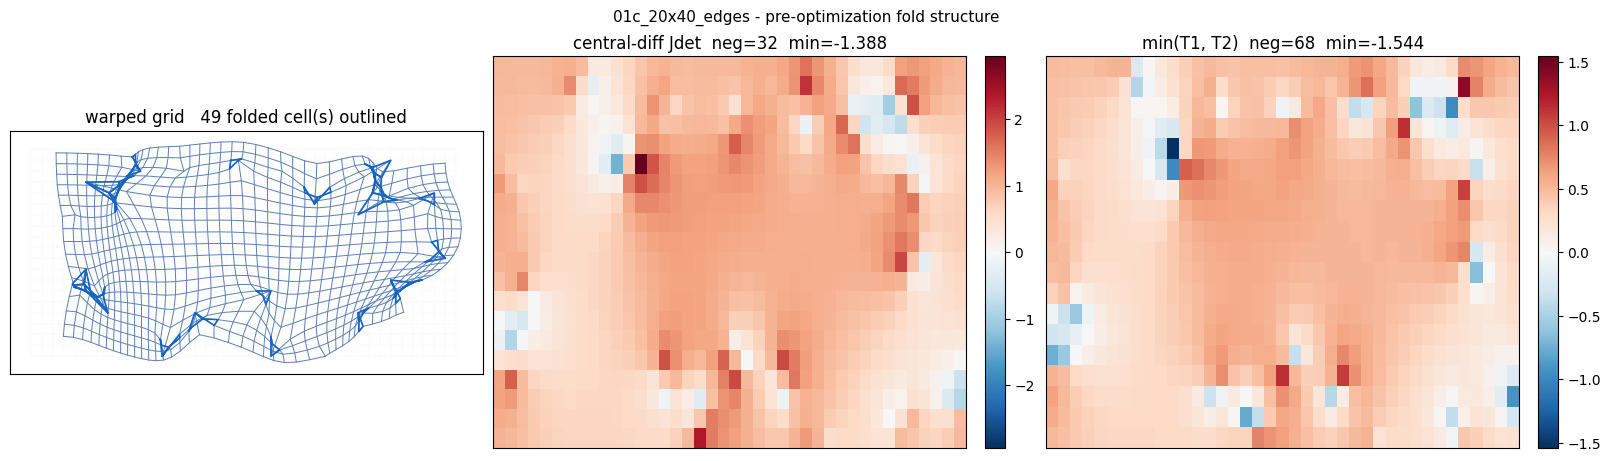

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), layout='constrained')

ax = axes[0]
yy, xx = np.mgrid[:H_, :W_]
gx = xx + phi_init[1]; gy = yy + phi_init[0]
for i in range(H_):
    ax.plot(xx[i], yy[i], color='#f4f4f4', lw=0.3)
for j in range(W_):
    ax.plot(xx[:, j], yy[:, j], color='#f4f4f4', lw=0.3)
for i in range(H_):
    ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.7)
for j in range(W_):
    ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.7)
tri_init = triangle_sign_areas2D(phi_init)
bad_init = np.argwhere(tri_init.min(axis=0) <= 0)
for (cy, cx) in bad_init:
    px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
    py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
    ax.plot(px, py, color='#1565c0', lw=1.2)
ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_title(f'warped grid   {len(bad_init)} folded cell(s) outlined')
ax.set_xticks([]); ax.set_yticks([])

vmax_cd = float(max(abs(m0['jd']).max(), 1.0))
im = axes[1].imshow(m0['jd'], cmap='RdBu_r', vmin=-vmax_cd, vmax=vmax_cd, aspect='auto')
axes[1].set_title(f"central-diff Jdet  neg={m0['n_cd']}  min={m0['min_cd']:+.3f}")
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

tri_min0 = tri_init.min(axis=0)
vmax_tr = float(max(abs(tri_min0).max(), 1.0))
im2 = axes[2].imshow(tri_min0, cmap='RdBu_r', vmin=-vmax_tr, vmax=vmax_tr, aspect='auto')
axes[2].set_title(f"min(T1, T2)  neg={m0['n_tr']}  min={m0['min_tr']:+.3f}")
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f'{CASE_KEY} - pre-optimization fold structure', fontsize=11)
plt.show()

## Run each constraint formulation

CD and FD use scipy's default numerical Jacobian (no `jac=` passed); 2-tri gets the analytical Jacobian + warm-start. Each run uses `maxiter=500` and the default `ftol`.

In [7]:
results = {}
for name, fn in [('cd', run_cd_slsqp), ('fd', run_fd_slsqp), ('2tri', run_2tri_best_slsqp)]:
    print(f'>>> {name}')
    r = fn(phi_init)
    r['qi'] = list_intersecting_quads(r['phi'])
    results[name] = r
    print(f"    nit={r['nit']:>4d}  time={r['time']:>7.2f}s  success={str(r['success']):<5s}  status={r['status']}")
    print(f"    neg_CD={r['n_cd']:>3d}  neg_FD={r['n_fd']:>3d}  neg_TR={r['n_tr']:>3d}  QI={len(r['qi']):>3d}  L2={r['l2']:.3f}")
    print(f"    min_TR={r['min_tr']:+.4f}   message: {r['message']}")

>>> cd


    nit=  10  time=  24.61s  success=True   status=0
    neg_CD=  0  neg_FD= 30  neg_TR= 64  QI=327  L2=2.910
    min_TR=-1.4062   message: Optimization terminated successfully
>>> fd


    nit=  11  time=  19.86s  success=True   status=0
    neg_CD= 28  neg_FD=  0  neg_TR= 32  QI=301  L2=1.969
    min_TR=-1.9702   message: Optimization terminated successfully
>>> 2tri


    nit= 109  time= 417.29s  success=True   status=0
    neg_CD=  4  neg_FD=  0  neg_TR=  0  QI=  0  L2=5.487
    min_TR=+0.0100   message: Optimization terminated successfully


### Cross-variant summary table

In [8]:
variants = [('initial', None), ('(A) CD',  'cd'), ('(B) FD',  'fd'), ('(C) 2tri (best)', '2tri')]
hdr = f"{'variant':<18s}  {'nit':>4s}  {'time':>8s}  {'success':>8s}  {'neg_CD':>6s}  {'neg_FD':>6s}  {'neg_TR':>6s}  {'QI':>5s}  {'L2':>6s}"
print(hdr)
print('-' * len(hdr))
print(f"{'initial':<18s}  {'-':>4s}  {'-':>8s}  {'-':>8s}  {m0['n_cd']:>6d}  {m0['n_fd']:>6d}  {m0['n_tr']:>6d}  {len(qi0):>5d}  {'-':>6s}")
for label, key in variants[1:]:
    r = results[key]
    print(f"{label:<18s}  {r['nit']:>4d}  {r['time']:>7.2f}s  {str(r['success']):>8s}  "
          f"{r['n_cd']:>6d}  {r['n_fd']:>6d}  {r['n_tr']:>6d}  {len(r['qi']):>5d}  {r['l2']:>6.3f}")

variant              nit      time   success  neg_CD  neg_FD  neg_TR     QI      L2
-----------------------------------------------------------------------------------
initial                -         -         -      32      34      68    334       -
(A) CD                10    24.61s      True       0      30      64    327   2.910
(B) FD                11    19.86s      True      28       0      32    301   1.969
(C) 2tri (best)      109   417.29s      True       4       0       0      0   5.487


## Grid deformation across variants

Row 1: warped quad grid, cells with `min(T1, T2) <= 0` outlined in dark blue. Row 2: per-cell `min(T1, T2)` heatmap (`RdBu_r`, shared scale).

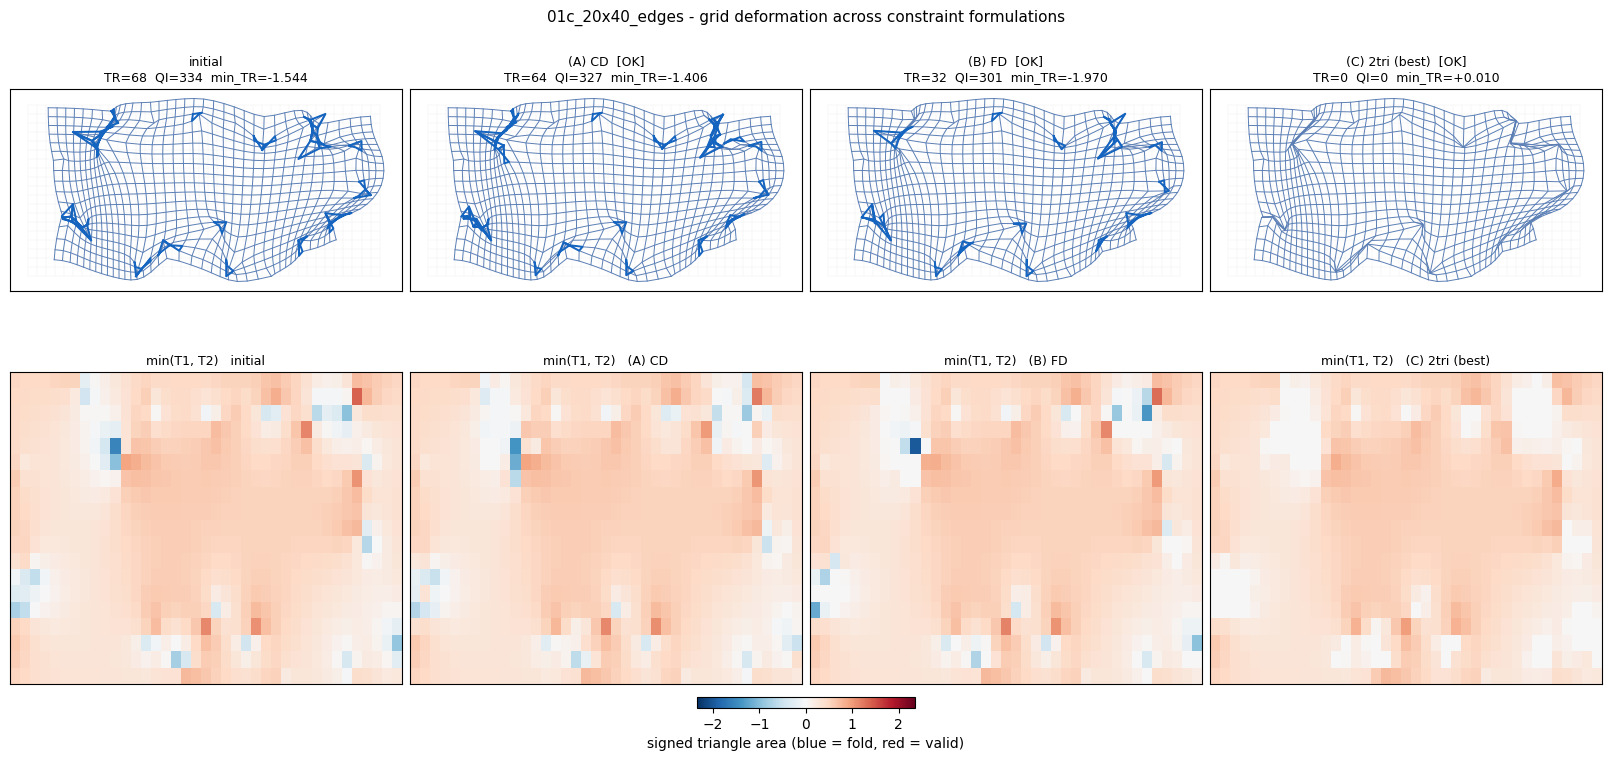

In [9]:
def plot_warped_grid(ax, phi, title, highlight_folds=True):
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.3)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.3)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.7)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.7)
    if highlight_folds:
        tri = triangle_sign_areas2D(phi)
        bad = np.argwhere(tri.min(axis=0) <= 0)
        for (cy, cx) in bad:
            px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(px, py, color='#1565c0', lw=1.4)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])


panels = [
    ('initial',          phi_init,       m0,      len(qi0), None),
    ('(A) CD',           results['cd']['phi'],   results['cd'],   len(results['cd']['qi']),   results['cd']),
    ('(B) FD',           results['fd']['phi'],   results['fd'],   len(results['fd']['qi']),   results['fd']),
    ('(C) 2tri (best)',  results['2tri']['phi'], results['2tri'], len(results['2tri']['qi']), results['2tri']),
]
vmax_tri = max(abs(m['tri']).max() for _, _, m, _, _ in panels)
NL = chr(10)

fig, axes = plt.subplots(2, len(panels), figsize=(4 * len(panels), 7.5), layout='constrained')
for k, (label, phi, m, qi_n, res) in enumerate(panels):
    if res is None:
        line1 = label
    else:
        tag = 'OK' if res['success'] else 'FAIL'
        line1 = f'{label}  [{tag}]'
    line2 = f"TR={m['n_tr']}  QI={qi_n}  min_TR={m['min_tr']:+.3f}"
    plot_warped_grid(axes[0, k], phi, line1 + NL + line2)

    tri_min = m['tri'].min(axis=0)
    im = axes[1, k].imshow(tri_min, cmap='RdBu_r', vmin=-vmax_tri, vmax=vmax_tri, aspect='auto')
    axes[1, k].set_title(f'min(T1, T2)   {label}', fontsize=9)
    axes[1, k].set_xticks([]); axes[1, k].set_yticks([])

cbar = fig.colorbar(im, ax=axes[1, :], orientation='horizontal',
                    fraction=0.035, pad=0.04, shrink=0.55)
cbar.set_label('signed triangle area (blue = fold, red = valid)')
plt.suptitle(f'{CASE_KEY} - grid deformation across constraint formulations', fontsize=11)
plt.show()

## Jacobian heatmaps - three measures, four rows

One row per variant; three columns for CD Jdet / FD Jdet / `min(T1, T2)`. Shared colormap scale across rows for each column so you can read, e.g., which CD-flagged cells survive into each corrected field.

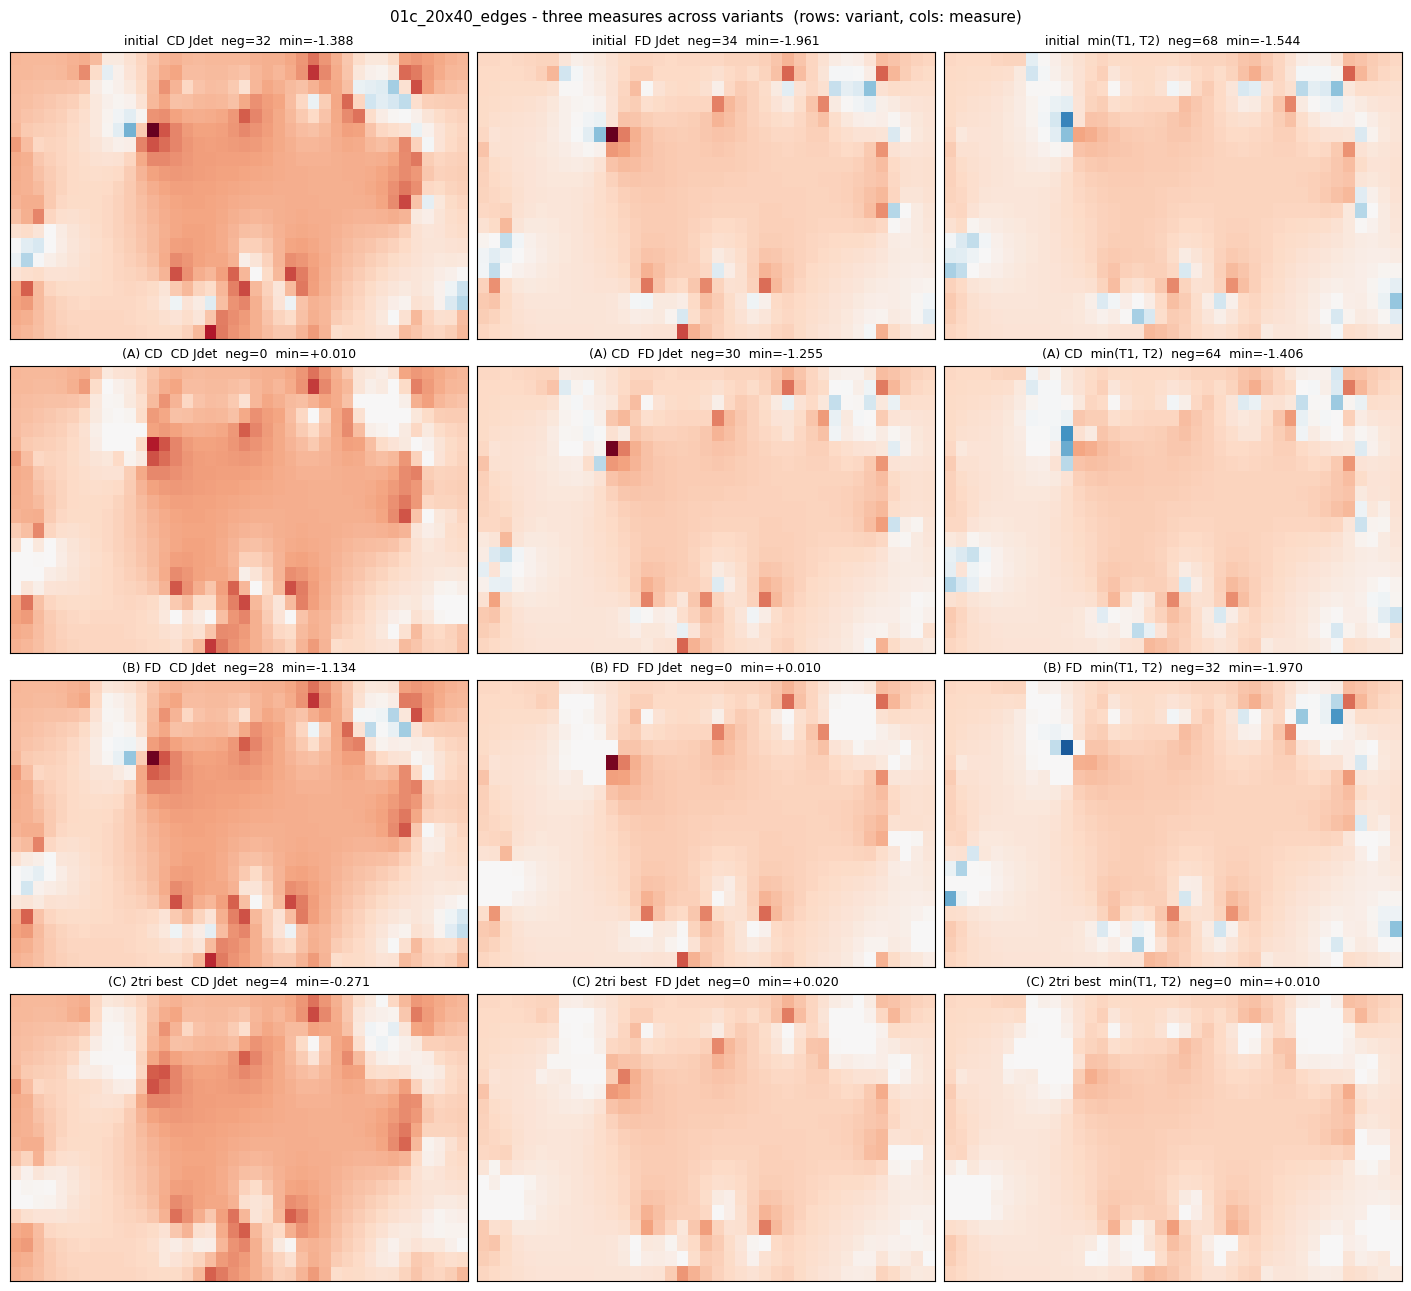

In [10]:
panels_m = [('initial', m0),
             ('(A) CD',        results['cd']),
             ('(B) FD',        results['fd']),
             ('(C) 2tri best', results['2tri'])]
vmax_cd = max(abs(m['jd']).max()  for _, m in panels_m)
vmax_fd = max(abs(m['fd']).max()  for _, m in panels_m)
vmax_tr = max(abs(m['tri']).max() for _, m in panels_m)

fig, axes = plt.subplots(len(panels_m), 3, figsize=(14, 3.2 * len(panels_m)), layout='constrained')
for i, (label, m) in enumerate(panels_m):
    axes[i, 0].imshow(m['jd'], cmap='RdBu_r', vmin=-vmax_cd, vmax=vmax_cd, aspect='auto')
    axes[i, 0].set_title(f"{label}  CD Jdet  neg={m['n_cd']}  min={m['min_cd']:+.3f}", fontsize=9)
    axes[i, 1].imshow(m['fd'], cmap='RdBu_r', vmin=-vmax_fd, vmax=vmax_fd, aspect='auto')
    axes[i, 1].set_title(f"{label}  FD Jdet  neg={m['n_fd']}  min={m['min_fd']:+.3f}", fontsize=9)
    tri_min = m['tri'].min(axis=0)
    axes[i, 2].imshow(tri_min, cmap='RdBu_r', vmin=-vmax_tr, vmax=vmax_tr, aspect='auto')
    axes[i, 2].set_title(f"{label}  min(T1, T2)  neg={m['n_tr']}  min={m['min_tr']:+.3f}", fontsize=9)
    for ax in axes[i]:
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f'{CASE_KEY} - three measures across variants  (rows: variant, cols: measure)', fontsize=11)
plt.show()

## Per-pixel debug - worst initial pixels across variants

Rows are the K=6 worst initial pixels by `min(T1, T2)`; columns are the four variants. Reading a row shows how the same pixel's T1/T2 evolves as the constraint changes.

top 6 worst pixels (by initial min_TR): [(10, 4), (10, 5), (33, 2), (38, 16), (16, 17), (1, 14)]


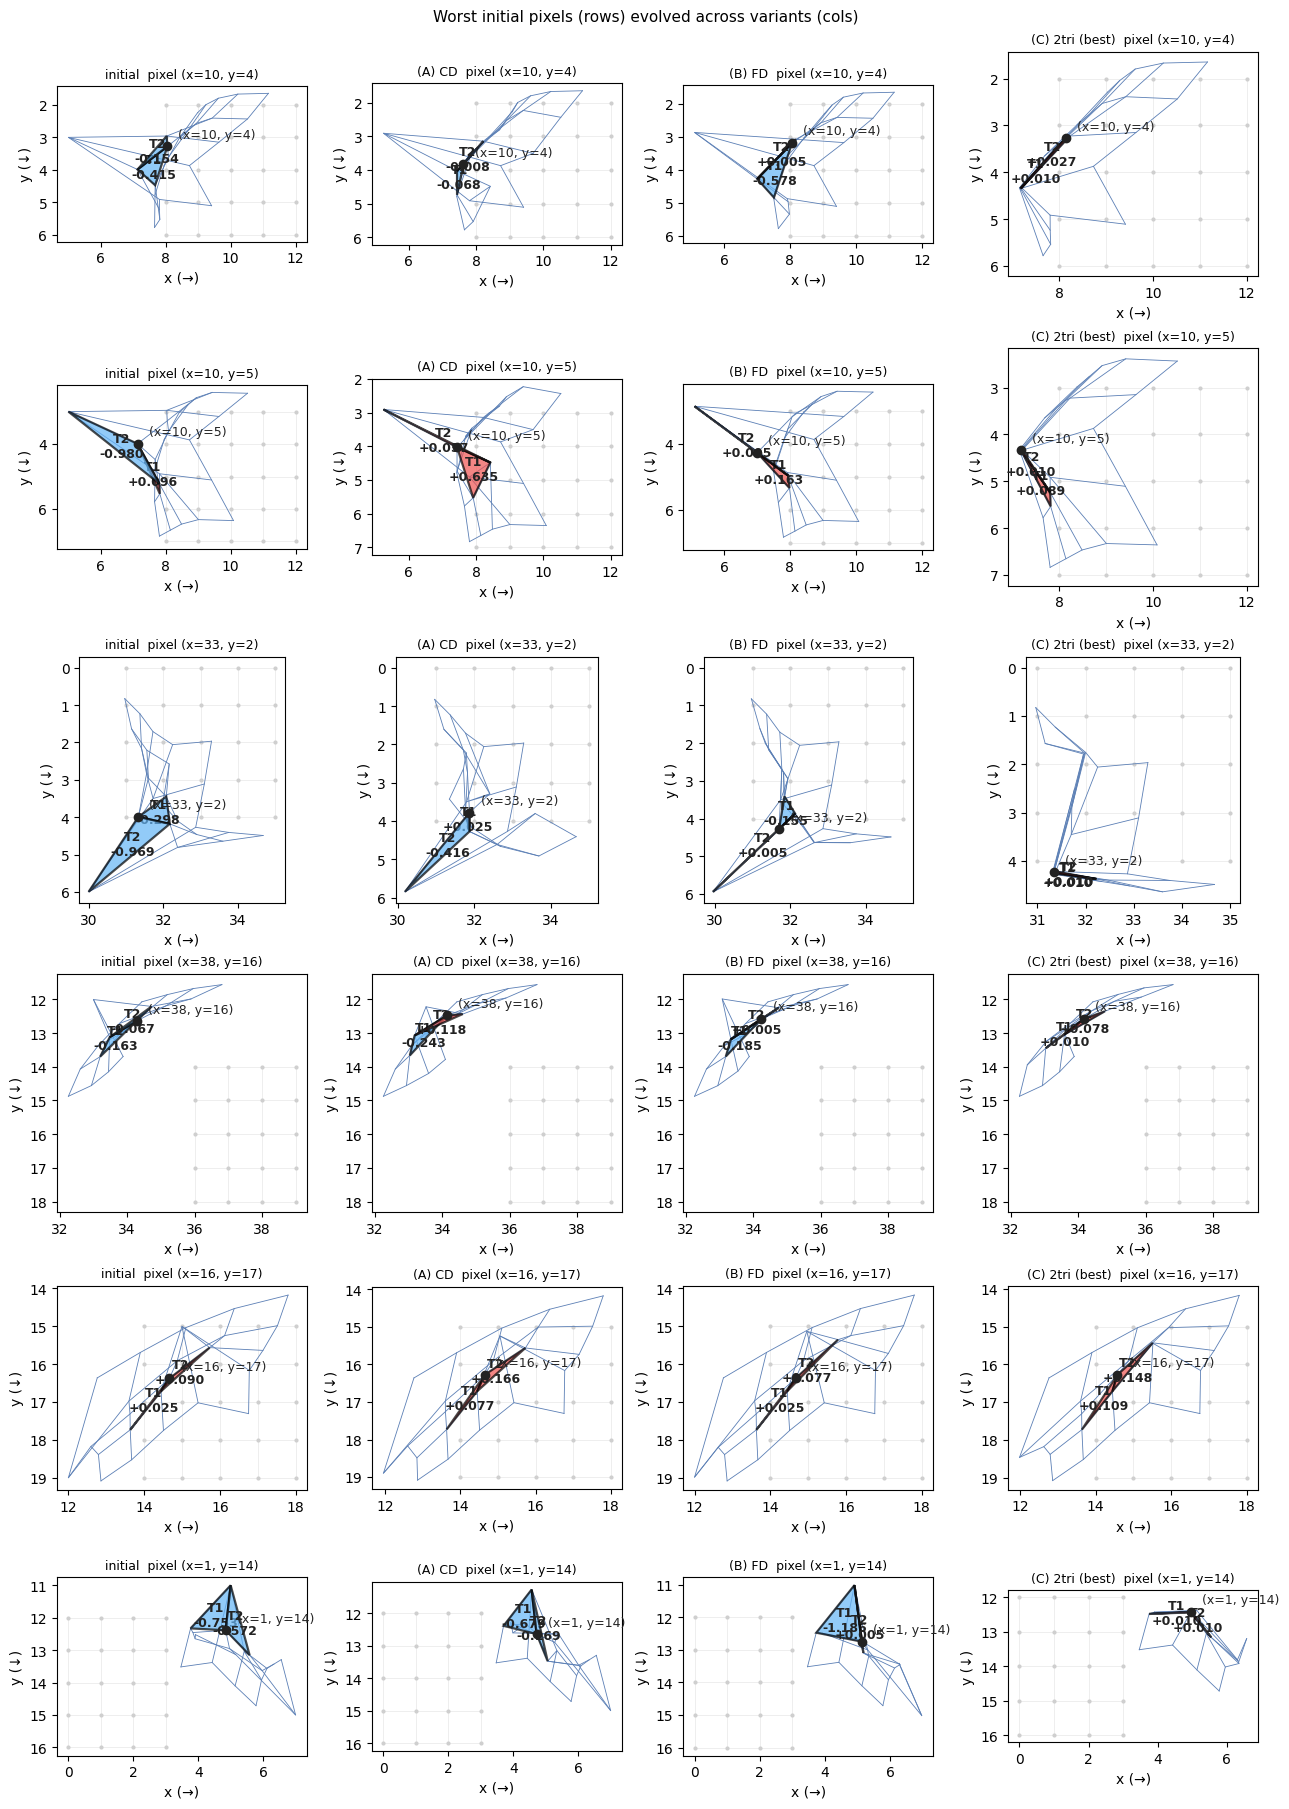

In [11]:
labels = [
    ('initial',              phi_init),
    ('(A) CD',                results['cd']['phi']),
    ('(B) FD',                results['fd']['phi']),
    ('(C) 2tri (best)',       results['2tri']['phi']),
]

K = 6
tri0 = triangle_sign_areas2D(phi_init)
tri0_min = tri0.min(axis=0)
worst_cells = np.argsort(tri0_min.ravel())[:K]
nr, nc = tri0_min.shape
seen = set(); worst_pixels = []
for flat in worst_cells:
    cy, cx = divmod(int(flat), nc)
    p = (cx if cx >= 1 else cx + 1, cy)
    if p not in seen:
        seen.add(p); worst_pixels.append(p)
worst_pixels = worst_pixels[:K]
print(f'top {len(worst_pixels)} worst pixels (by initial min_TR):', worst_pixels)

fig, axes = plt.subplots(len(worst_pixels), len(labels),
                          figsize=(3.2 * len(labels), 3.0 * len(worst_pixels)),
                          layout='constrained', squeeze=False)
for row, (x, y) in enumerate(worst_pixels):
    for col, (label, phi) in enumerate(labels):
        plot_triangle_debug(phi, x=x, y=y, ax=axes[row, col], show_formula=False)
        axes[row, col].set_title(f'{label}  pixel (x={x}, y={y})', fontsize=9)
plt.suptitle('Worst initial pixels (rows) evolved across variants (cols)', fontsize=11)
plt.show()

## Disagreement overlay - where CD/FD pass but 2-tri still flags

The cells where each constraint converged under *its own* measure but the 2-triangle check still reports a fold. Those are the silent failures - folds a pipeline would miss if it trusted CD or FD convergence.

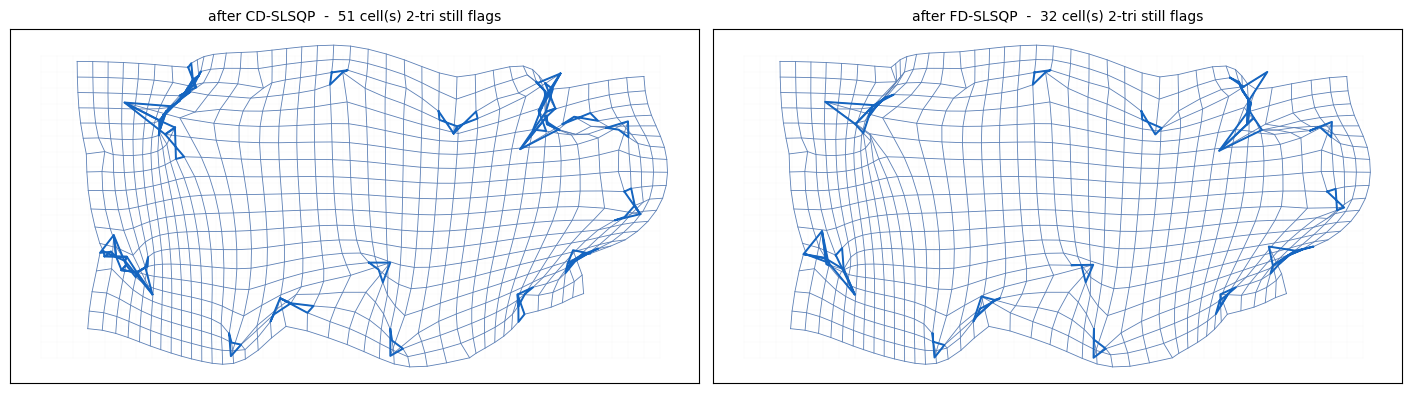

In [12]:
def plot_disagreement(phi, title, ax):
    dy, dx = phi[0], phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f8f8f8', lw=0.3)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f8f8f8', lw=0.3)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.6)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.6)
    tri = triangle_sign_areas2D(phi)
    bad = np.argwhere(tri.min(axis=0) <= 0)
    for (cy, cx) in bad:
        px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
        py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
        ax.plot(px, py, color='#1565c0', lw=1.4)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(f'{title}  -  {len(bad)} cell(s) 2-tri still flags', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout='constrained')
plot_disagreement(results['cd']['phi'], 'after CD-SLSQP', axes[0])
plot_disagreement(results['fd']['phi'], 'after FD-SLSQP', axes[1])
plt.show()

## Summary

On `01c_20x40_edges`, one specific hard case, the **constraint** choice matters at least as much as the Jacobian choice:

- **(A) CD-constraint SLSQP** tends to finish quickly with `success=True` and `neg_CD=0` but leaves most initial 2-triangle folds in place. The per-pixel central-difference stencil is too averaged to see the fine-grained fold structure of edge-localized large displacements.
- **(B) FD-constraint SLSQP** does better at detection (per-cell is stricter than per-pixel) and makes real progress, but still leaves residual 2-triangle folds because one forward-difference Jdet per cell can't see bowties where one triangle flips and the other doesn't.
- **(C) 2-triangle constraint + analytical Jac + warm-start** is the only variant that drives every measure to zero here, including the global quad-intersection count `QI`.

The disagreement overlay at the end pinpoints the exact cells where the weaker constraints silently leave folds behind. In a correction pipeline that certifies validity via `triangle_sign_areas2D` (e.g. before downstream resampling), running CD or FD SLSQP first is not a safe substitute.

For a multi-case version of the same comparison (synthetic small cases), see [04_constraint-comparison.ipynb](04_constraint-comparison.ipynb). For the real-slice version, see [06_real-slice.ipynb](06_real-slice.ipynb). For the Jacobian-method comparison on this same hard case, see [05_solver-engineering.ipynb](05_solver-engineering.ipynb).